# 311 Manhattan 2025 — Data Collection & Cleaning

**Revision notes (addressing reviewer feedback):**
- Replaced fixed-limit ASC ordering with random sampling to avoid early-month bias
- Added total count query per month to understand true population size
- Enhanced cleaning pipeline: outlier filtering, zip code validation, sample-size threshold

## Step 0 — Check actual monthly record counts (population size)

In [1]:
import requests
import pandas as pd
import numpy as np

BASE_URL = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"

months = [
    ("2025-01-01", "2025-02-01"),
    ("2025-02-01", "2025-03-01"),
    ("2025-03-01", "2025-04-01"),
    ("2025-04-01", "2025-05-01"),
    ("2025-05-01", "2025-06-01"),
    ("2025-06-01", "2025-07-01"),
    ("2025-07-01", "2025-08-01"),
    ("2025-08-01", "2025-09-01"),
    ("2025-09-01", "2025-10-01"),
    ("2025-10-01", "2025-11-01"),
    ("2025-11-01", "2025-12-01"),
    ("2025-12-01", "2026-01-01"),
]

month_counts = {}
for start, end in months:
    params = {
        "$select": "count(*)",
        "$where": f"created_date >= '{start}T00:00:00' AND created_date < '{end}T00:00:00' AND borough = 'MANHATTAN'"
    }
    resp = requests.get(BASE_URL, params=params)
    total = int(resp.json()[0]["count"])
    month_counts[start[:7]] = total
    print(f"{start[:7]}: {total:,} records in population")

print(f"\nFull-year population total: {sum(month_counts.values()):,}")

2025-01: 61,331 records in population
2025-02: 50,815 records in population
2025-03: 55,235 records in population
2025-04: 57,917 records in population
2025-05: 61,309 records in population
2025-06: 62,791 records in population
2025-07: 61,425 records in population
2025-08: 59,887 records in population
2025-09: 61,132 records in population
2025-10: 69,727 records in population
2025-11: 61,943 records in population
2025-12: 61,501 records in population

Full-year population total: 725,013


## Step 1 — Data Collection with Random Sampling

Use **offset** random jumping to draw an approximately representative sample.
- If monthly population ≤ 5,000 → pull full dataset (no sampling needed)
- If monthly population > 5,000 → randomly sample ~1,700 records using random offsets

This replaces the original `$order: created_date ASC` approach which systematically captured only early-month complaints.

In [2]:
import math

SAMPLE_PER_MONTH = 1700  
BATCH_SIZE = 100         

def random_sample_month(start, end, population, target=SAMPLE_PER_MONTH, batch=BATCH_SIZE):
    where_clause = (
        f"created_date >= '{start}T00:00:00' "
        f"AND created_date < '{end}T00:00:00' "
        f"AND borough = 'MANHATTAN'"
    )

    if population <= target:
        params = {"$where": where_clause, "$limit": population, "$offset": 0}
        return requests.get(BASE_URL, params=params).json()

    n_batches = math.ceil(target / batch)
    max_offset = population - batch
    offsets = np.random.choice(max_offset, size=n_batches, replace=False)

    records = []
    for offset in offsets:
        params = {
            "$where": where_clause,
            "$limit": batch,
            "$offset": int(offset),
            "$order": "created_date ASC"
        }
        batch_data = requests.get(BASE_URL, params=params).json()
        records.extend(batch_data)

    return records



np.random.seed(42) 
all_data = []

for start, end in months:
    month_key = start[:7]
    population = month_counts[month_key]
    records = random_sample_month(start, end, population)
    all_data.extend(records)
    print(f"{month_key}: sampled {len(records):,} / {population:,} (population)")

df_raw = pd.DataFrame(all_data)
print(f"\nRaw collected total: {len(df_raw):,} records")
df_raw.to_csv("311_2025_manhattan_raw.csv", index=False)

2025-01: sampled 1,700 / 61,331 (population)
2025-02: sampled 1,700 / 50,815 (population)
2025-03: sampled 1,700 / 55,235 (population)
2025-04: sampled 1,700 / 57,917 (population)
2025-05: sampled 1,700 / 61,309 (population)
2025-06: sampled 1,700 / 62,791 (population)
2025-07: sampled 1,700 / 61,425 (population)
2025-08: sampled 1,700 / 59,887 (population)
2025-09: sampled 1,700 / 61,132 (population)
2025-10: sampled 1,700 / 69,727 (population)
2025-11: sampled 1,700 / 61,943 (population)
2025-12: sampled 1,700 / 61,501 (population)

Raw collected total: 20,400 records


## Step 2 — Data Cleaning

In [3]:
df = pd.read_csv("311_2025_manhattan_raw.csv")

print("=" * 50)
print(f"[START] Rows: {len(df):,} | Columns: {df.shape[1]}")
print("=" * 50)

# ── 2.1 Deduplication ──────────────────────────────
df = df.drop_duplicates(subset="unique_key")
print(f"[After dedup] Rows: {len(df):,}")

# ── 2.2 Datetime parsing ───────────────────────────
df["created_date"] = pd.to_datetime(df["created_date"])
df["closed_date"]  = pd.to_datetime(df["closed_date"], errors="coerce")

# ── 2.3 Derived time features ──────────────────────
df["year"]        = df["created_date"].dt.year
df["month"]       = df["created_date"].dt.month
df["season"]      = df["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring",  4: "Spring", 5: "Spring",
    6: "Summer",  7: "Summer", 8: "Summer",
    9: "Fall",   10: "Fall",  11: "Fall"
})
df["day_of_week"] = df["created_date"].dt.dayofweek   # 0=Mon, 6=Sun
df["hour"]        = df["created_date"].dt.hour
df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int)

# ── 2.4 Drop rows missing key analysis variables ───
before = len(df)
df = df.dropna(subset=["complaint_type", "closed_date", "incident_zip"])
print(f"[After dropna on complaint_type/closed_date/incident_zip] "
      f"Dropped: {before - len(df):,} | Remaining: {len(df):,}")

# ── 2.5 Standardise text fields ────────────────────
text_cols = ["complaint_type", "descriptor", "borough", "city", "location_type"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].str.strip().str.title()

# ── 2.6 Response hours ─────────────────────────────
df["response_hours"] = (
    df["closed_date"] - df["created_date"]
).dt.total_seconds() / 3600

# Remove negative response times (data error)
before = len(df)
df = df[df["response_hours"] >= 0]
print(f"[After removing negative response_hours] "
      f"Dropped: {before - len(df):,} | Remaining: {len(df):,}")

# Winsorise extreme outliers (> 99th percentile) — keep but flag
p99 = df["response_hours"].quantile(0.99)
df["response_hours_flag"] = (df["response_hours"] > p99).astype(int)
print(f"[Outlier flag] response_hours > {p99:.1f}h (99th pct): "
      f"{df['response_hours_flag'].sum():,} rows flagged")

# ── 2.7 ZIP code validation ────────────────────────
df["incident_zip"] = df["incident_zip"].astype(str).str.extract(r"(\d{5})")[0]
before = len(df)
df = df.dropna(subset=["incident_zip"])   # drop malformed zips
print(f"[After ZIP validation] Dropped: {before - len(df):,} | Remaining: {len(df):,}")

# ── 2.8 ZIP code sample-size threshold ────────────
# Exclude ZIP codes with fewer than 50 total records (unreliable for clustering)
ZIP_THRESHOLD = 50
zip_counts = df["incident_zip"].value_counts()
valid_zips = zip_counts[zip_counts >= ZIP_THRESHOLD].index
before = len(df)
df_filtered = df[df["incident_zip"].isin(valid_zips)]
print(f"\n[ZIP threshold >= {ZIP_THRESHOLD}]")
print(f"  ZIP codes retained: {len(valid_zips)} / {len(zip_counts)}")
print(f"  Rows retained: {len(df_filtered):,} / {before:,}")
print(f"  Rows excluded: {before - len(df_filtered):,}")

# ── 2.9 Select final columns ───────────────────────
keep_cols = [
    "unique_key",
    # Time
    "created_date", "closed_date",
    "year", "month", "season", "day_of_week", "hour", "is_weekend",
    # Complaint
    "complaint_type", "descriptor", "agency", "location_type",
    # Geography
    "incident_zip", "incident_address", "community_board",
    # Resolution
    "resolution_description",
    # Response time
    "response_hours", "response_hours_flag",
]
keep_cols = [c for c in keep_cols if c in df_filtered.columns]
df_final = df_filtered[keep_cols].copy()

print("\n" + "=" * 50)
print(f"[FINAL] Rows: {len(df_final):,} | Columns: {df_final.shape[1]}")
print("=" * 50)

df_final.to_csv("311_2025_manhattan_cleaned.csv", index=False)
print("Saved → 311_2025_manhattan_cleaned.csv")

[START] Rows: 20,400 | Columns: 44
[After dedup] Rows: 19,921
[After dropna on complaint_type/closed_date/incident_zip] Dropped: 907 | Remaining: 19,014
[After removing negative response_hours] Dropped: 9 | Remaining: 19,005
[Outlier flag] response_hours > 4603.6h (99th pct): 191 rows flagged
[After ZIP validation] Dropped: 0 | Remaining: 19,005

[ZIP threshold >= 50]
  ZIP codes retained: 40 / 75
  Rows retained: 18,743 / 19,005
  Rows excluded: 262

[FINAL] Rows: 18,743 | Columns: 19
Saved → 311_2025_manhattan_cleaned.csv


## Step 3 — Quality Assurance Checks

Monthly record counts:
month
1     1464
2     1608
3     1626
4     1525
5     1630
6     1551
7     1566
8     1582
9     1615
10    1475
11    1572
12    1529
CV (coefficient of variation): 0.036
(Lower CV = more balanced monthly distribution)

Top 15 complaint types:
complaint_type
Heat/Hot Water                1995
Noise - Residential           1844
Illegal Parking               1762
Noise - Street/Sidewalk       1501
Encampment                     824
Noise - Commercial             708
Noise                          593
Unsanitary Condition           555
Vendor Enforcement             438
Homeless Person Assistance     422
Plumbing                       413
Dirty Condition                371
Water System                   360
Street Condition               318
Paint/Plaster                  311

ZIP codes in final dataset: 40
Min records per ZIP: 55
Max records per ZIP: 975
Median records per ZIP: 476

response_hours stats:
  Mean:   242.9h
  Median: 7.6h
  Std:    768.3h
  99th p

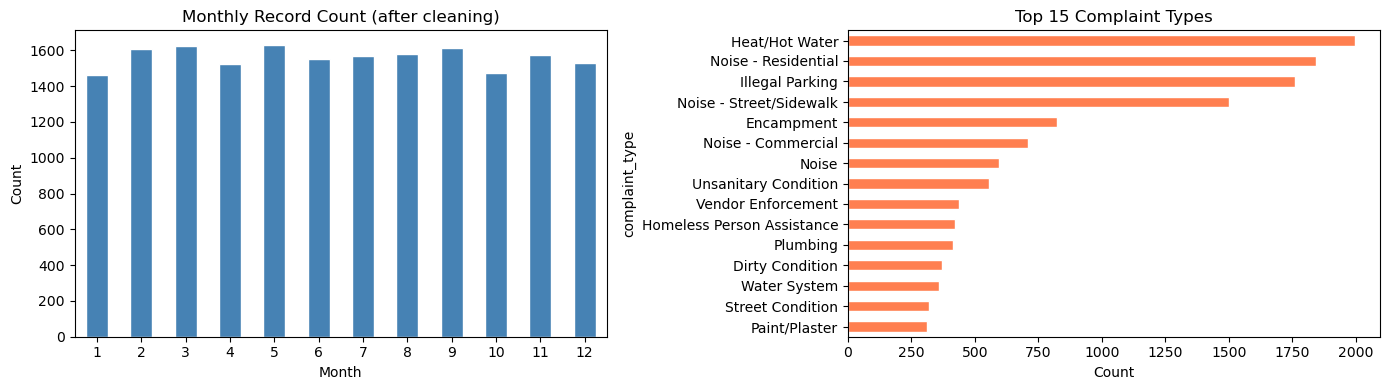

QA plot saved → qa_checks.png


In [4]:
import matplotlib.pyplot as plt

df = pd.read_csv("311_2025_manhattan_cleaned.csv", parse_dates=["created_date"])

# ── QA 1: Monthly distribution (check for sampling balance) ───
monthly = df.groupby("month").size()
print("Monthly record counts:")
print(monthly.to_string())
print(f"CV (coefficient of variation): {monthly.std()/monthly.mean():.3f}")
print("(Lower CV = more balanced monthly distribution)\n")

# ── QA 2: Top complaint types ──────────────────────────────────
print("Top 15 complaint types:")
print(df["complaint_type"].value_counts().head(15).to_string())

# ── QA 3: ZIP code distribution ───────────────────────────────
zip_dist = df["incident_zip"].value_counts()
print(f"\nZIP codes in final dataset: {len(zip_dist)}")
print(f"Min records per ZIP: {zip_dist.min()}")
print(f"Max records per ZIP: {zip_dist.max()}")
print(f"Median records per ZIP: {zip_dist.median():.0f}")

# ── QA 4: Response hours distribution ─────────────────────────
rh = df["response_hours"]
print(f"\nresponse_hours stats:")
print(f"  Mean:   {rh.mean():.1f}h")
print(f"  Median: {rh.median():.1f}h")
print(f"  Std:    {rh.std():.1f}h")
print(f"  99th pct: {rh.quantile(0.99):.1f}h")
print(f"  Flagged outliers: {df['response_hours_flag'].sum():,} rows")

# ── QA 5: Season balance ───────────────────────────────────────
print("\nSeason distribution:")
print(df["season"].value_counts().to_string())

# ── QA 6: Plot monthly counts ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Monthly Record Count (after cleaning)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

df["complaint_type"].value_counts().head(15).sort_values().plot(
    kind="barh", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Top 15 Complaint Types")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig("qa_checks.png", dpi=150, bbox_inches="tight")
plt.show()
print("QA plot saved → qa_checks.png")